# Figure2(Stackedbar) for bertopic

In [1]:
visualization_target = input("INPUT 'visualization_target RUN_ID'(e.g., run_id_10): ")
model_in_run = input("INPUT 'model_in_run'(e.g., bert_based, lda, tag): ")

In [2]:
import os 
import numpy as np
import pandas as pd
from datetime import datetime
import pprint

from setting_for_sda.color_setting import Color_Setting
from setting_for_sda.date_setting import Date_Setting
from setting_for_sda.path_setting import path_list

import lib.stats.stats as st
from lib.utils.statistics import *
from matplotlib import pyplot as plt

import matplotlib as mpl
import lib.visualization.plot_generator as PlotGen
import lib.visualization.font_setting as font_setting
from lib.visualization.distribution_collector import (proportion_calc_for_topic, 
                                                      collect_top_bottom_topic)
mpl.rcParams['font.family'] = font_setting.init_font()

Helvetica /home/mghan/.fonts/Helvetica/Helvetica Oblique.ttf
Registered font name: Helvetica


In [3]:
color_list = Color_Setting.color_list
alpha_list = [1, 1, 0.7]

In [4]:
viz_dir = f'{path_list["data_root_dir"]}/result/{model_in_run}/{visualization_target}'
data_dir = f"{viz_dir}/data"
option_dict = load_json(f"{viz_dir}/option.json")

output_dir = './fig/'
date_range = 'Weekly'

std_date = Date_Setting[option_dict['year_range']]['std_date']

pprint.pprint(option_dict)

{'data_dir': '/mnt/hdd/mghan/so_data_availability/data/public_for_260105/questions/typescript/2020to2025',
 'model': 'BERTopic',
 'model_option': {'clustering': {'n_clusters': 50, 'name': 'kmeans'},
                  'embedding_model': None,
                  'model_type': 'text',
                  'nr_topics': None,
                  'vectorizer': 'CountVectorizer'},
 'run_id': '30',
 'save_dir': '/mnt/hdd/mghan/so_data_availability/result/bert_based/run_id_30',
 'selected_tags': None,
 'snapshot': 'public_for_260105',
 'visualization': {'n': 10},
 'year_range': '2020to2025'}


In [5]:
df = load_df(data_dir, ['id' , 'creationdate' , 'title', 'tags', 'body', 'Topic'])

In [6]:
df['creationdate'] = pd.to_datetime(df['creationdate'], format="mixed").dt.normalize()
df['rel_week'] = ((df['creationdate'] - std_date).dt.days // 7)

In [7]:
print(df['creationdate'].min())
print(df['creationdate'].max())

2020-12-02 00:00:00
2025-11-25 00:00:00


In [8]:
df[df['rel_week'] == 52]

,id,creationdate,title,tags,body,Document,Topic,rel_week
77608,77567916,2023-11-29,The types export by declaration file can not b...,<typescript><vue.js><visual-studio-code><vite>,"<p>I'm new ts programmer, I have something con...","I'm new ts programmer, I have something confus...",1,52
77609,77568166,2023-11-29,How to dynamically change displayed content(wi...,<reactjs><typescript><react-hooks><jsx>,<p>I am implementing the client side for a tic...,I am implementing the client side for a tic-ta...,21,52
77610,77568196,2023-11-29,Type '{ recipe: null; }' is not assignable to ...,<typescript><next.js>,<p>Working on a ChatGPT-integrated app that so...,Working on a ChatGPT-integrated app that sourc...,26,52
77611,77568238,2023-11-29,How to combine 2 Decorators to process files t...,<javascript><node.js><typescript><nestjs><back...,<p>How to combine 2 Decorators to process file...,How to combine 2 Decorators to process files t...,15,52
77612,77568252,2023-11-29,how to require each object in an array to exac...,<reactjs><typescript>,<p>I'm trying to create an array of objects th...,I'm trying to create an array of objects that ...,13,52
...,...,...,...,...,...,...,...,...
77934,77608870,2023-12-05,How to send verification email to new a cognit...,<typescript><amazon-web-services><amazon-cogni...,<p>I have the following method for signup in a...,I have the following method for signup in a ty...,42,52
77935,77609284,2023-12-05,Mix of types in array in an interface causing ...,<typescript>,<p>I am defining three things:</p>\n<pre class...,I am defining three things:\nexport interface ...,13,52
77936,77609488,2023-12-05,Nx publishable library: 'rootDir' is expected ...,<typescript><rollupjs><nrwl-nx><nrwl><nx-works...,<p>I created a publishable Nx library that has...,I created a publishable Nx library that has a ...,1,52
77937,77609678,2023-12-05,Next.js: `onSubmit` not executing callback fun...,<javascript><reactjs><node.js><typescript><nex...,"<p>In my Next.js module, I have a form declare...","In my Next.js module, I have a form declared a...",34,52


In [9]:
prop_df = proportion_calc_for_topic(df, 'rel_week', 'Topic')

In [10]:
top10list, mid30list, bot10list = collect_top_bottom_topic(prop_df, 'rel_week', 'Topic', 'proportion')

list_10 = {'Top 20% Topics' : top10list, 
               'Bottom 20% Topics' : bot10list}


df_dict = {'Top 20% Topics'       : prop_df[prop_df['Topic'].isin(top10list)],   
          'Bottom 20% Topics'     : prop_df[prop_df['Topic'].isin(bot10list)]}

    


In [11]:
# calculate entropy and gini by weekly manner
df_coef = {'Entropy' : prop_df.groupby(['rel_week'])['proportion'].apply(lambda x : calculate_entropy(x)).to_frame(name='Entropy').reset_index(),
           'Gini'    : prop_df.groupby(['rel_week'])['proportion'].apply(lambda x : calculate_gini(x)).to_frame(name = 'Gini').reset_index()}

In [12]:
plot_gen = PlotGen.PlotGen()

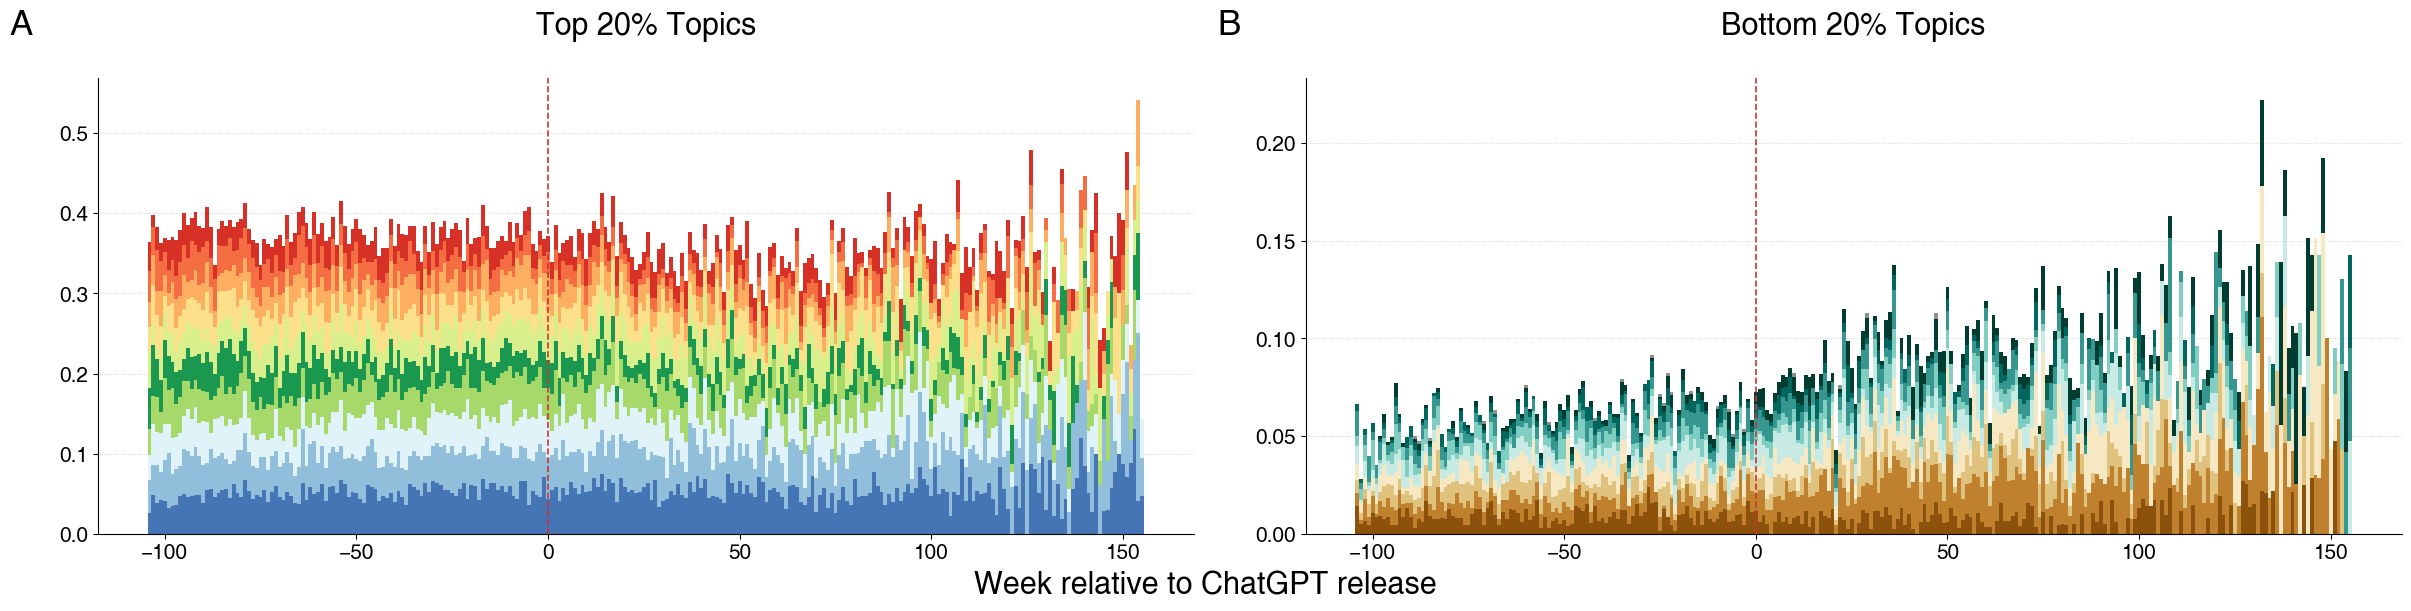

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(24, 6), constrained_layout=True)

panel_labels = ['A', 'B', 'C', 'D']
### stacked topic plots
for i, (title, proportion) in enumerate(df_dict.items()):

    plot_gen.draw_topic_stack(
        axs[i],
        title,
        proportion,
        list_10[title],
        color_list[i],
        alpha_list[i],
        panel_labels[i]
    )


fig.supxlabel("Week relative to ChatGPT release", fontsize=22)

plt.savefig(f"{output_dir}{option_dict['model']}_{option_dict['year_range']}", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
panel_labels = ['A', 'B', 'C', 'D']
### stacked topic plots
for i, (title, proportion) in enumerate(df_dict.items()):

    proportion.groupby('rel_week')['proportion'].sum().reset_index()

In [ ]:
def draw_complexity_regression(ax, x, y, st_chow_1year,
                               F_stat_1, p_value_1, title,
                               panel_label=''):

    split_idx = np.where(x < 0)[0][-1] + 1

    x1 = x[:split_idx]
    x2 = x[split_idx:]

    # scatter
    ax.scatter(x, y, color='darkgray', alpha=0.7, s=10, marker='x')

    # Full model
    ax.plot(x, st_chow_1year.y_predict,
            linestyle="--", color="black",
            linewidth=1.5, label='Overall fit')

    # Before ChatGPT
    ax.plot(x1, st_chow_1year.y1_predict,
            linewidth=1.5, label='Before ChatGPT')

    ax.fill_between(
        x1,
        st_chow_1year.y1_predict - st_chow_1year.y1_conf_interval,
        st_chow_1year.y1_predict + st_chow_1year.y1_conf_interval,
        alpha=0.15
    )

    # After ChatGPT
    ax.plot(x2, st_chow_1year.y2_predict,
            linewidth=1.5, label='After ChatGPT')

    ax.fill_between(
        x2,
        st_chow_1year.y2_predict - st_chow_1year.y2_conf_interval,
        st_chow_1year.y2_predict + st_chow_1year.y2_conf_interval,
        alpha=0.15
    )

    # vertical line
    ax.axvline(x=0, color='#CC3333', linestyle='--', linewidth=1.2, zorder=5)

    # p-value text
    p_txt = '$p < 0.001$' if p_value_1 < 0.001 else f'$p = {p_value_1:.3f}$'
    p_color = '#CC3333' if p_value_1 < 0.05 else 'gray'

    # title
    ax.text(
        0.5, 1.08,
        f'Changes in {title}',
        transform=ax.transAxes,
        fontsize=font_setting.font_setting['title'],
        ha='center',
        va='bottom'
    )

    # p-value
    ax.text(
        0.5, 1.02,
        p_txt,
        ha='center',
        fontsize=font_setting.font_setting['p-value'],
        color=p_color,
        transform=ax.transAxes
    )

    # panel label
    if panel_label:
        ax.text(
            -0.08, 1.08,
            panel_label,
            transform=ax.transAxes,
            fontsize=font_setting.font_setting['panel'],
            fontweight='bold',
            va='bottom',
            ha='left'
        )

    # axis labels
    ax.set_xlabel("Week relative to ChatGPT release", fontsize=font_setting.font_setting['label'])
    ax.set_ylabel("Percentage(%)", fontsize=font_setting.font_setting['label'])

    # ticks
    ax.tick_params(axis='both', labelsize=font_setting.font_setting['tick'])

    # spine
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # grid
    ax.yaxis.grid(True, linestyle=':', linewidth=0.5,
                  color='gray', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

    # legend
    ax.legend(fontsize=font_setting.font_setting['legend'], frameon=False)

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(12,24), constrained_layout=True, sharey=True)
label_dict = {'A' : 'Basic', 'B' : 'Intermediate', 'C':'Advanced'}

for i, (title, proportion) in enumerate(df_dict.items()):
    chk_cnt = proportion.groupby('rel_week')['proportion'].sum().reset_index()
    x = chk_cnt['rel_week'].values
    y = chk_cnt['proportion'].values

    st_chow = st.Stats(x, y, 2, 0.95, chk_cnt[chk_cnt['rel_week'] ==0].index.values[0])
    F_stat, p_value = st_chow.chow_test()
    draw_complexity_regression(
        ax[i],
        x,
        y,
        st_chow,
        F_stat,
        p_value,
        title=f"{title}",
        # panel_label=f"{label}"
    )



plt.savefig(
    f"{output_dir}/{visualization_target}.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
top10list

In [ ]:
df.loc[df['rel_week'] > 130, 'Topic'].value_counts()

In [ ]:
df.loc[df['rel_week'] > 104, 'Topic'].value_counts()